In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/Users/villasenor/science/github/jvillasr/MINATO')
import minato
import matplotlib.pyplot as plt
from astropy.constants import c

In [3]:
c

<<class 'astropy.constants.codata2018.CODATA2018'> name='Speed of light in vacuum' value=299792458.0 uncertainty=0.0 unit='m / s' reference='CODATA 2018'>

Create random observing times during night time

In [4]:
N = 12
days = np.random.randint(58000, 59000, N)

# choose evening (21–24 h) vs morning (0–06 h)
p_evening = (3/24) / ((3/24)+(6/24))  # weight by window lengths (optional)
evening = np.random.rand(N) < p_evening

fracs = np.empty(N)
# evening: 21/24 … 1.0
fracs[evening] = np.random.uniform(21/24, 1.0, evening.sum())
# morning: 0.0 … 6/24
fracs[~evening] = np.random.uniform(0.0, 6/24, (~evening).sum())

mjds_night = days + fracs
print(mjds_night)

[58070.03966321 58416.99220426 58228.92679435 58943.08489046
 58920.96908552 58637.98163992 58583.02960277 58901.22911496
 58666.13039641 58064.91193632 58699.07521445 58177.06613246]


In [43]:
observing_dict = {
    # 'ID' : np.array([f'epoch_{id}' for id in np.arange(1, N+1)]),
    # 'ID' : np.array(['star01']*N),
    'ID' : np.array([f'star01_{x}' for x in range(1, N+1)]),
    'MJD' : np.sort(mjds_night),
    'mean_rv' : np.random.uniform(20, 80, N),
    'mean_rv_er' : np.random.normal(0.1, 0.01, N),
}
df_obs = pd.DataFrame(observing_dict)
df_obs

,ID,MJD,mean_rv,mean_rv_er
0,star01_1,58064.911936,33.767731,0.095461
1,star01_2,58070.039663,75.017754,0.104314
2,star01_3,58177.066132,45.393387,0.096538
3,star01_4,58228.926794,35.391397,0.110324
4,star01_5,58416.992204,78.786142,0.101319
5,star01_6,58583.029603,47.396090,0.094243
6,star01_7,58637.981640,55.098975,0.110622
7,star01_8,58666.130396,22.051191,0.108166
8,star01_9,58699.075214,27.688245,0.097798
9,star01_10,58901.229115,26.027645,0.103071


In [44]:
df_obs.to_csv('ravel_tutorial/SB1/JDs.txt', index=False, sep=' ', header=False, columns=['ID', 'MJD'])

## Create an SB1

In [7]:
import minato.binary_population as binSim

In [10]:
simulator = binSim.BinarySimulations()

simulator.M1_min = 18
simulator.M1_max = 19
simulator.q_min = 0.35
simulator.q_max = 0.4
simulator.logP_min = np.log10(20)
simulator.logP_max = np.log10(60)

coverage_dict = simulator.load_data(df_obs)

simsys = simulator.simulate_mock_observations(pi=0.0, kappa=0.0, eta=-0.5, gamma=-2.35, N=1, f_bin=1,)
simsys

,synthetic_ID,real_ID_used,is_binary,M1,q,P,Tp,e,omega_deg,gamma,K1,K2,i_deg,a,dRV_max,sigma_d,rv_mean,n_eps,rv_array,rv_array2
0,SYN_0000,star01,True,18.642553,0.388973,31.527567,30.156846,0.052835,5.074725,-0.473301,50.40076,129.573784,115.567819,0.577823,86.635192,607.900725,20.270449,12,"[5.241338449004613, 47.80772720107996, -27.273...","[-14.986223382356615, -124.92298431205754, 67...."


In [11]:
print('M2 = ', simsys['q']*simsys['M1'])

M2 =  0    7.251458
dtype: float64


In [12]:
simsys['rv_array'].to_list()

[array([  5.24133845,  47.8077272 , -27.27375349,  51.90167827,
         48.51521101,   9.63176316,  49.69269188,  26.89443541,
         38.38362392, -19.01153521,  46.19572543, -34.73351377])]

In [17]:
simsys['rv_array2'].to_list()

[array([ -14.98622338, -124.92298431,   67.64276681, -135.26344678,
        -126.60495015,  -26.51238769, -129.65346576,  -70.11263248,
        -101.17833944,   47.03375258, -120.94202292,   87.16507178])]

[  5.24133845  47.8077272  -27.27375349  51.90167827  48.51521101
   9.63176316  49.69269188  26.89443541  38.38362392 -19.01153521
  46.19572543 -34.73351377]


<ErrorbarContainer object of 3 artists>

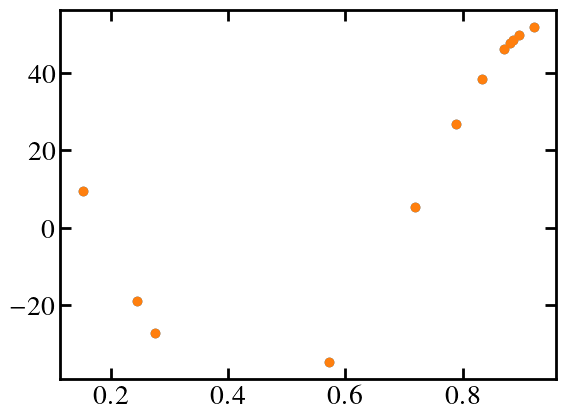

In [13]:
phase = (np.array(df_obs['MJD']) / simsys['P'].values) % 1
print(simsys['rv_array'].values[0])
plt.plot(phase, simsys['rv_array'].values[0], 'o', color='C0', label='simulated RVs')
plt.errorbar(phase, simsys['rv_array'].values[0], yerr=df_obs['mean_rv_er'], fmt='o', color='C1', label='observed RVs')

Now that we have the RVs, we can create the synthetic spectra

In [2]:
from scipy.signal import fftconvolve
from scipy.interpolate import interp1d

def assign_model_parameters(simulated_mass, model_table, target_logg=4.2, tol=0.2):
    """
    Given a simulated stellar mass and a model table, return the best matching row (model)
    for the star. We fix log g to target_logg within a tolerance, and then select the row
    with the closest MASS value.
    
    Parameters:
      simulated_mass (float): Simulated stellar mass in M_sun.
      model_table (pd.DataFrame): DataFrame containing columns 'MASS' and 'LOGG', among others.
      target_logg (float): The log g value to match (default: 4.2).
      tol (float): Tolerance for log g matching.
      
    Returns:
      best_model (pd.Series): The row from model_table that best matches the simulated mass.
    """
    # Filter models with log g within tolerance of target_logg
    df_filtered = model_table[np.abs(model_table['LOGG'] - target_logg) < tol]
    
    # If no models fall within the desired log g range, use all models
    if df_filtered.empty:
        df_filtered = model_table

    # Compute the absolute differences between the simulated mass and the model masses
    mass_diff = np.abs(df_filtered['MASS'] - simulated_mass)
    
    # Select the row with the minimum difference in mass
    best_index = mass_diff.idxmin()
    best_model = df_filtered.loc[best_index]
    return best_model

def construct_model_filename(model_row):
    """
    Given a model row from the table, construct the filename for the atmosphere model.
    
    The filename pattern is assumed to be: 'gal-ob-vd3_{T_eff_kK}-{LOG_G}_line.txt'
    where T_eff is given in kiloKelvin.
    """
    T_eff_kK = int(round(model_row['T_EFF'] / 1000.))
    # Often LOG_G can be formatted, e.g., without decimals (or with one decimal)
    logg_str = f"{model_row['LOGG']:.1f}".replace('.', '')
    filename = f"gal-ob-vd3_{T_eff_kK}-{logg_str}_line.txt"
    return filename

def read_model_spectrum(filename):
    """
    Read an atmospheric model spectrum from a text file.
    
    Assumes the file has at least two columns:
      - Column 0: Wavelength (in Angstroms)
      - Column 1: Flux

    Parameters:
      filename (str): Path to the model file.
      
    Returns:
      wavelength (np.ndarray): Array of wavelengths.
      flux (np.ndarray): Array of fluxes.
    """
    try:
        data = np.loadtxt(filename)
        wavelength = data[:, 0]
        flux = data[:, 1]
    except Exception as e:
        print(f"Error loading file {filename}: {e}")
        return None, None
    return wavelength, flux

def read_and_plot_model_spectra(primary_filename, secondary_filename=None, path='', plot=False, xlim=None):
    """
    Read and optionally plot one or two model spectra.
    
    Parameters:
      primary_filename (str): The path/filename for the primary star model.
      secondary_filename (str, optional): The path/filename for the secondary star model.
      plot (bool): If True, plot the spectrum (or both spectra if a secondary is provided).
      
    Returns:
      results (dict): A dictionary with keys 'primary' and, if available, 'secondary'. Each is a tuple
                      (wavelength, flux).
    """
    results = {}
    
    # Read primary spectrum.
    wave1, flux1 = read_model_spectrum(path+primary_filename)
    if wave1 is None:
        print(f"Primary model file '{primary_filename}' could not be loaded.")
        return None
    results['primary'] = (wave1, flux1)
    
    # Read secondary spectrum if provided.
    if secondary_filename is not None:
        wave2, flux2 = read_model_spectrum(path+secondary_filename)
        if wave2 is None:
            print(f"Secondary model file '{secondary_filename}' could not be loaded.")
        else:
            results['secondary'] = (wave2, flux2)
    
    # Plot the spectra if requested.
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(wave1, flux1, label=f"Primary: {primary_filename}", lw=2)
        if 'secondary' in results:
            plt.plot(wave2, flux2, label=f"Secondary: {secondary_filename}", lw=2)
        if xlim is not None:
          plt.xlim(xlim)
        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux")
        plt.title("Model Spectra")
        plt.legend()
        plt.show()
    
    return results

# Speed of light in km/s
c_kms = c.to('km/s').value  

def rotational_kernel_vspace(vsini: float,
                             epsilon: float,
                             dv: float) -> tuple[np.ndarray, int]:
    """
    Build the *velocity-space* rotational-broadening kernel
    for a linear-in-velocity (constant-Δv) spectral grid.

    The kernel implements the linear limb-darkening prescription
    from Gray *Stellar Photospheres* (3rd ed., 2005, Eq. 18.14):

        K(x) ∝ (1-ε) √(1-x²) + ½ π ε (1-x²),   |x| ≤ 1 ,
    
    where ``x = v / v_max`` and ``v_max = vsini``.

    Parameters
    ----------
    vsini : float
        Projected rotational velocity *vsini* in km/s.  
        This sets the half-width of the kernel.
    epsilon : float
        Linear limb-darkening coefficient (0 ≤ ε ≤ 1).  
        Typical values: 0.6 for B-type stars in the blue,
        0.3 for solar-type stars.
    dv : float
        Velocity step per pixel (km/s pixel^-1) *on the input logλ grid*.
        The kernel is sampled at this spacing.

    Returns
    -------
    kernel : 1D `~numpy.ndarray`
        Normalised convolution kernel whose sum equals unity.
        Length is ``2*npix + 1``.
    npix : int
        Half-width of the kernel in pixels, useful for padding:
        ``pad_width = npix``
    """
    vmax   = vsini
    npix   = int(np.ceil(vmax / dv))
    v      = np.arange(-npix, npix + 1) * dv
    x      = v / vmax

    kernel = np.zeros_like(x)
    inside = np.abs(x) <= 1.0
    x_in   = x[inside]

    kernel[inside] = (2.0 * (1.0 - epsilon) * np.sqrt(1.0 - x_in**2) +
                      0.5 * np.pi * epsilon * (1.0 - x_in**2))
    kernel /= kernel.sum()          # final normalisation

    return kernel, npix

def apply_rot_broadening_log(wave: np.ndarray,
                             flux: np.ndarray,
                             vsini: float,
                             epsilon: float = 0.6) -> np.ndarray:
    """
    Convolve a spectrum on a **log-wavelength grid** with a
    rotational-broadening kernel while preserving line centroids
    to << 0.01 km/s.

    Parameters
    ----------
    wave : 1D `~numpy.ndarray`
        Wavelength array **equally spaced in lnλ** (constant-Δv grid),
        units: Å or nm — only the *ratios* matter.
    flux : 1D `~numpy.ndarray`
        Flux array aligned with ``wave``.
    vsini : float
        Projected rotational velocity in km/s.
    epsilon : float, optional
        Linear limb‑darkening coefficient (default 0.6).

    Returns
    -------
    flux_rot : 1D `~numpy.ndarray`
        Rotationally broadened flux on the **same** wavelength grid.
    """
    # --- sanity check on grid uniformity in ln λ ---------------------------
    logλ  = np.log(wave)
    dlog  = np.diff(logλ)
    if not np.allclose(dlog, dlog[0], rtol=1e-6, atol=0):
        raise ValueError("`wave` must be sampled on a constant ln λ grid "
                         "(equal velocity steps). "
                         "Rebin with `SpectralCoord.log_wavelength` or "
                         "similar utilities before calling this function.")
    dv    = dlog[0] * c_kms        # km s⁻¹ per pixel

    kernel, npix = rotational_kernel_vspace(vsini, epsilon, dv)

    # --- FFT convolution with edge padding --------------------------------
    flux_pad   = np.pad(flux, npix, mode='edge')
    flux_conv  = fftconvolve(flux_pad, kernel, mode='same')[npix:-npix]

    return flux_conv

def apply_instrumental_resolution_log(
        wave: np.ndarray,
        flux: np.ndarray,
        R: float) -> np.ndarray:
    """
    Convolve a spectrum (sampled on a constant-Δv grid, i.e. equally
    spaced in lnλ) with a Gaussian instrumental profile of resolving
    power *R* = λ / Δλ.

    On a log-wavelength grid the instrumental profile has a *constant*
    FWHM in velocity:

        FWHM_v  =  c / R     [km/s],

    so one Gaussian kernel suffices over the entire order and does **not**
    shift line centroids.

    Parameters
    ----------
    wave : 1D `~numpy.ndarray`
        Wavelength array **uniformly spaced in ln λ**.
    flux : 1D `~numpy.ndarray`
        Flux values aligned with ``wave``.
    R : float
        Resolving power of the spectrograph (λ / Δλ).

    Returns
    -------
    flux_conv : 1D `~numpy.ndarray`
        Flux after convolution with the instrumental PSF.
    """
    # ---- check that the grid really is log‑linear ------------------------
    logλ = np.log(wave)
    dlog = np.diff(logλ)
    if not np.allclose(dlog, dlog[0], rtol=1e-6, atol=0):
        raise ValueError("`wave` must be uniformly spaced in lnλ "
                         "(constant Δv grid).")

    # velocity step per pixel on this grid
    dv    = dlog[0] * c_kms                # km s⁻¹ pixel⁻¹

    # Gaussian width in velocity units
    FWHM_v   = c_kms / R
    sigma_v  = FWHM_v / 2.355
    sigma_px = sigma_v / dv               # width in *pixels*

    # build kernel ±4σ wide
    half = int(np.ceil(4.0 * sigma_px))
    v_px = np.arange(-half, half + 1)      # pixel offsets
    kernel = np.exp(-0.5 * (v_px / sigma_px) ** 2)
    kernel /= kernel.sum()

    # FFT convolution with edge padding (avoids continuum tilt)
    flux_pad  = np.pad(flux, half, mode='edge')
    flux_conv = fftconvolve(flux_pad, kernel, mode='same')[half:-half]

    return flux_conv

def apply_broadening_and_resolution(wave, flux, vsini, R, epsilon=0.6, plot=False, xlim=None, dv=1.0):
    """
    Apply rotational broadening and then instrumental resolution convolution on a
    constant-Δv (log-λ) grid.
    
    Parameters:
      wavelength (np.ndarray): Wavelength array (Angstroms).
      flux (np.ndarray): Input flux spectrum.
      vsini (float): Projected rotational velocity (km/s) for rotational broadening.
      R (float): Instrumental resolving power.
      epsilon (float): Limb-darkening coefficient (default 0.6).
      plot (bool): If True, plot intermediate steps.
    
    Returns:
      flux_final (np.ndarray): The final spectrum after both broadening processes.
    """
    # Compute a common log-λ grid and resample the input spectrum.
    lambda_master = compute_common_log_grid()
    new_flux = resample_to_λ_master(wave, flux, lambda_master)

    # Apply rotational broadening
    flux_rot = apply_rot_broadening_log(lambda_master, new_flux, vsini, epsilon)
    
    # Optionally plot the rotationally broadened spectrum.
    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(lambda_master, new_flux, label="Original", lw=2)
        plt.plot(lambda_master, flux_rot, label=f"Rotationally Broadened (v sin i = {vsini} km/s)", lw=2)
        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux")
        if xlim is not None:
            plt.xlim(xlim)
        plt.title("Rotational Broadening")
        plt.legend()
        plt.show()
    
    # Apply the instrumental profile (Gaussian, constant FWHM_v = c/R)
    flux_final = apply_instrumental_resolution_log(lambda_master, flux_rot, R)
    print('Length of flux after instrumental resolution:', len(flux_final))
    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(wave, flux_rot, label="After Rotation", lw=2)
        plt.plot(wave, flux_final, label=f"With Instrumental Resolution (R = {R})", lw=2)
        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux")
        if xlim is not None:
            plt.xlim(xlim)
        plt.title("Instrumental Convolution")
        plt.legend()
        plt.show()
    
    return lambda_master, flux_final

def compute_common_log_grid(lam_min=3901.0, lam_max=4599.0, dv = 1.0):
    """
    Create a common wavelength grid for spectra, equally spaced in lnλ.
    This is useful for resampling spectra to a common grid.
    Parameters
    ----------
    lam_min : float
        Minimum wavelength (Angstroms).
    lam_max : float
        Maximum wavelength (Angstroms).
    dv : float
        Velocity step per pixel (km/s).
    Returns
    -------
    λ_master : 1D ndarray
        Common wavelength grid, equally spaced in lnλ.
    """
    log_min = np.log(lam_min)
    log_max = np.log(lam_max)
    n_pix = int(round((log_max-log_min) * c_kms / dv)) + 1 
    log_grid = log_min + np.arange(n_pix) * dv / c_kms 
    λ_master = np.exp(log_grid)   
    return λ_master

def resample_to_λ_master(wave, flux, λ_master, kind='linear'):
    """
    Interpolate spectrum onto the common λ_master grid.
    Parameters
    ----------
    wave : 1D ndarray
        Original wavelength array (Angstroms).
    flux : 1D ndarray
        Original flux array.
    λ_master : 1D ndarray
        Common wavelength grid (Angstroms).
    kind : str
        Interpolation type (default 'linear').
    Returns
    -------
    flux_resampled : 1D ndarray
        Flux resampled onto the common grid.
    """
    from scipy.interpolate import interp1d
    interp = interp1d(wave, flux, kind=kind,
                      bounds_error=False, fill_value="extrapolate")
    return interp(λ_master)

def doppler_shift(wavelength, flux, v):
    """
    Apply Doppler shift to a spectrum.
    
    Parameters:
      wavelength (np.ndarray): Original wavelength array
      flux (np.ndarray): Flux array
      v (float or np.ndarray): Radial velocity in km/s (positive = redshift)
      
    Returns:
      np.ndarray: Shifted flux at the original wavelength points
    """
    from scipy.interpolate import interp1d
    # Check if v is a scalar or array
    if np.isscalar(v):
        shifted_wavelength = wavelength * (1 + v / c_kms)
        interp_func = interp1d(shifted_wavelength, flux, bounds_error=False, fill_value="extrapolate")
        return interp_func(wavelength)
    else:
        # For array of velocities, return a 2D array of fluxes
        shifted_fluxes = np.zeros((len(v), len(wavelength)))
        for i, vel in enumerate(v):
            shifted_wavelength = wavelength * (1 + vel / c_kms)
            interp_func = interp1d(shifted_wavelength, flux, bounds_error=False, fill_value="extrapolate")
            shifted_fluxes[i] = interp_func(wavelength)
        return shifted_fluxes

def create_composite_spectrum(wavelength, primary_flux, secondary_flux, rv_primary, rv_secondary, logl_primary, logl_secondary):
    """
    Create a composite spectrum for a binary by applying RV shifts to the
    primary and secondary spectra, scaling the secondary by the flux ratio.
    
    Parameters:
      wavelength (np.ndarray): Wavelength array
      primary_flux (np.ndarray): Flux of primary star
      secondary_flux (np.ndarray): Flux of secondary star
      rv_primary (float or np.ndarray): Radial velocity of primary star in km/s
      rv_secondary (float or np.ndarray): Radial velocity of secondary star in km/s
      logl_primary (float): Log luminosity of primary star
      logl_secondary (float): Log luminosity of secondary star
      
    Returns:
      np.ndarray: The final composite spectrum or array of spectra if RVs are arrays
    """
    # Compute the flux ratio using the model log luminosities
    flux_ratio = 10**(logl_secondary - logl_primary)

    # Calculate fractional contributions
    primary_fraction = 1 / (1 + flux_ratio)
    secondary_fraction = flux_ratio / (1 + flux_ratio)
    print(f"Primary fraction: {primary_fraction}, Secondary fraction: {secondary_fraction}")
    
    # Check if the RVs are scalar or arrays
    if np.isscalar(rv_primary) and np.isscalar(rv_secondary):
        # Simple case - single RV values
        shifted_primary = primary_fraction * doppler_shift(wavelength, primary_flux, rv_primary)
        shifted_secondary = secondary_fraction * doppler_shift(wavelength, secondary_flux, rv_secondary)
        composite = shifted_primary + shifted_secondary
        return shifted_primary, shifted_secondary, composite
    else:
        # For array RVs, make sure they have the same length
        if len(rv_primary) != len(rv_secondary):
            raise ValueError("Primary and secondary RV arrays must have the same length")
        
        # Get the shifted fluxes for each RV
        shifted_primary = doppler_shift(wavelength, primary_flux, rv_primary)
        shifted_secondary = doppler_shift(wavelength, secondary_flux, rv_secondary)

        # Add the fluxes with proper scaling
        composite_fluxes = primary_fraction * shifted_primary + secondary_fraction * shifted_secondary

        shifted_secondary = shifted_secondary * secondary_fraction + (1 - secondary_fraction)
        shifted_primary = shifted_primary * primary_fraction + (1 - primary_fraction)

        return shifted_primary, shifted_secondary, composite_fluxes
    
def add_noise(spectrum, snr=25):
    """
    Add Gaussian noise to a spectrum to achieve a specified S/N.

    Parameters:
        spectrum (np.ndarray): Continuum-normalized spectrum (continuum = 1)
        snr (float): Desired signal-to-noise ratio in the continuum

    Returns:
        np.ndarray: Noisy spectrum
    """
    noise_std = 1.0 / snr  # Standard deviation of the noise
    noise = np.random.normal(loc=0.0, scale=noise_std, size=spectrum.shape)
    noisy_spectrum = spectrum + noise
    return noisy_spectrum

def measure_rv_cc(wavelength, composite_spectra, template_spectrum, velocity_range=(-100, 100), velocity_step=1.0, 
                  true_vel=None, wavelength_limits=None, plot_cc=False):
    """
    Measure the RV for each composite spectrum provided in a multi-dimensional array,
    performing cross-correlation over a specified wavelength range if provided.
    
    Parameters:
      wavelength (np.ndarray): Wavelength array.
      composite_spectra (np.ndarray): 2D array of composite spectra (each row is one spectrum, continuum normalized to 1).
      template_spectrum (np.ndarray): Template spectrum (1D, continuum normalized to 1).
      velocity_range (tuple): Min and max velocity in km/s over which to compute CC.
      velocity_step (float): Step size in km/s.
      true_vel (optional): True velocities (array-like) for plotting reference.
      wavelength_limits (tuple or None): Tuple (min_wavelength, max_wavelength) indicating the wavelength interval to use.
      plot_cc (bool): Whether to produce a plot of the CC function for each spectrum.
      
    Returns:
      list of tuples: Each tuple is (measured_rv, cc_peak) for an individual composite spectrum.
    """
    # Apply wavelength limits if provided.
    if wavelength_limits is not None:
        min_wave, max_wave = wavelength_limits
        mask = (wavelength >= min_wave) & (wavelength <= max_wave)
        wave_subset = wavelength[mask]
        template_subset = template_spectrum[mask]
    else:
        wave_subset = wavelength
        template_subset = template_spectrum

    # Create grid of velocities
    velocity_grid = np.arange(velocity_range[0], velocity_range[1] + velocity_step, velocity_step)
    
    cc_peak_list, measured_rv_list = [], []
    
    # Loop over each individual composite spectrum.
    for i, spec in enumerate(composite_spectra):
        # If a wavelength limit is provided, restrict the composite spectrum to the masked region.
        if wavelength_limits is not None:
            spec_subset = spec[mask]
        else:
            spec_subset = spec
        
        cc_values = []
        # Subtract the continuum (which is 1) so that CC focuses on the line features.
        comp_lines = spec_subset - 1
        for v in velocity_grid:
            # Doppler shift the template for the given velocity over the restricted wavelength range.
            shifted_template = doppler_shift(wave_subset, template_subset, v)
            # Remove continuum from the shifted template.
            tmpl_lines = shifted_template - 1
            # Compute the dot product as the CC measure.
            cc_val = np.sum(comp_lines * tmpl_lines)
            cc_values.append(cc_val)

        cc_values = np.array(cc_values)
        max_index = np.argmax(cc_values)
        measured_rv = velocity_grid[max_index]
        measured_rv_list.append(measured_rv)
        cc_peak_list.append(cc_values[max_index])


        if plot_cc:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8,4))
            plt.plot(velocity_grid, cc_values, marker='o')
            if true_vel is not None:
                plt.axvline(true_vel[i], color='g', linestyle='--', 
                            label=f"True RV = {true_vel[i]:.1f} km/s")
            plt.xlabel("Velocity shift (km/s)")
            plt.ylabel("Cross-correlation value")
            plt.title("Cross-correlation Function")
            plt.axvline(measured_rv, color='r', linestyle='--', 
                        label=f"Measured RV = {measured_rv:.1f} km/s")
            plt.legend()
            plt.show()

    return measured_rv_list, cc_peak_list

In [15]:
models_path = '/Users/villasenor/science/mpia/research/sdss/powr_models/griddl-gal-ob-vd3-line/'
models_data = pd.read_csv(models_path+'modelparameters.txt', comment='#', sep='\s+')
models_data

,MODEL,T_EFF,R_TRANS,MASS,LOGG,LOGL,LOGMDOT,V_INF
0,15-20,15000.0,20.9504,32.0,2.0,5.60,-4.6,210
1,15-22,15000.0,318.4365,23.8,2.2,5.27,-6.3,439
2,15-24,15000.0,502.3408,18.0,2.4,4.95,-6.8,478
3,15-26,15000.0,903.4271,13.4,2.6,4.62,-7.4,512
4,15-28,15000.0,1400.3815,10.1,2.8,4.30,-7.9,543
...,...,...,...,...,...,...,...,...
238,52-42,52000.0,114.9568,86.3,4.2,5.99,-5.8,3618
239,53-42,53000.0,103.2947,94.0,4.2,6.06,-5.7,3640
240,54-42,54000.0,93.9893,104.9,4.2,6.14,-5.6,3664
241,55-42,55000.0,85.7949,117.1,4.2,6.22,-5.5,3702


Primary mass: 18.64 M_sun, Secondary mass: 7.25 M_sun
Primary star temeprature: 34000.0
Secondary star temeprature: 21000.0
Primary spectrum filename: gal-ob-vd3_34-42_line.txt
Length of flux after instrumental resolution: 49349
Length of flux after instrumental resolution: 49349
Primary fraction: 0.947908550672625, Secondary fraction: 0.0520914493273749
Max dRV: 3


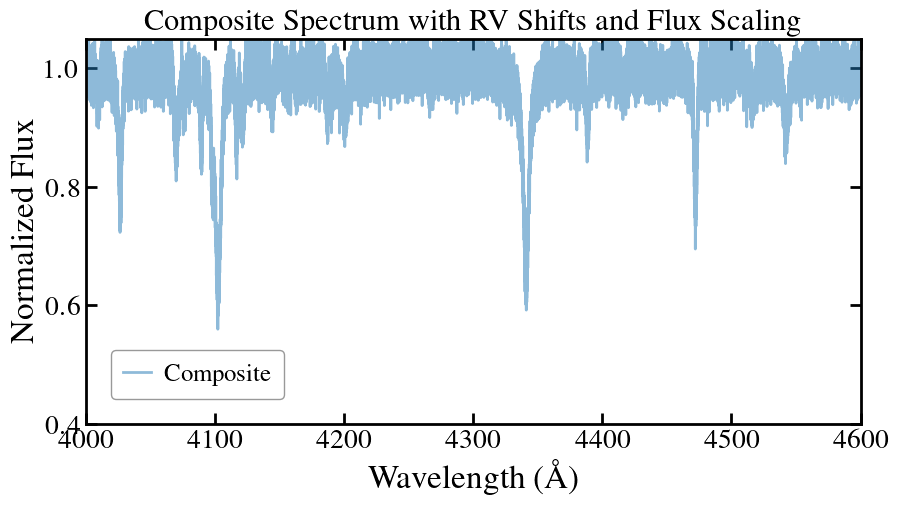

In [67]:
# 0. Define broadening and resolution parameters:
vsini = 100 # km/s
R = 5000      # Resolving power
snr = 50 # Signal-to-noise ratio

# 1. Get masses from the simulations:
masses1 = simsys['M1'].values
masses2 = simsys['q'].values * masses1
rvs1 = simsys['rv_array'].values
rvs2 = simsys['rv_array2'].values
periods = simsys['P'].values
drv_max = simsys['dRV_max'].values
all_cc_rvs = []
all_cc_peaks = []

# 2. Assign model parameters for each mass:
for m1, m2, rv1, rv2, drv, p in zip(masses1, masses2, rvs1, rvs2, drv_max, periods):
    print(f"Primary mass: {m1:.2f} M_sun, Secondary mass: {m2:.2f} M_sun")
    primary_model = assign_model_parameters(m1, models_data, target_logg=4.2)
    secondary_model = assign_model_parameters(m2, models_data, target_logg=4.2)
    print("Primary star temeprature:", primary_model['T_EFF'])
    print("Secondary star temeprature:", secondary_model['T_EFF'])
    # 3. Construct filenames for the models:
    primary_filename = construct_model_filename(primary_model)
    secondary_filename = construct_model_filename(secondary_model)
    print("Primary spectrum filename:", primary_filename)

    # 4. Read the model spectra:
    models = read_and_plot_model_spectra(primary_filename, secondary_filename, path=models_path, plot=False)

    # 5. Apply broadening and resolution to the models:
    wave1, flux1 = apply_broadening_and_resolution(models['primary'][0], models['primary'][1], vsini, R, epsilon=0.6, plot=False, xlim=(4535, 4565))
    wave2, flux2 = apply_broadening_and_resolution(models['secondary'][0], models['secondary'][1], vsini, R, epsilon=0.6, plot=False)

    # 6. Create the composite spectrum ():
    f_shift1, f_shift2, composite_flux = create_composite_spectrum(wave1, flux1, flux2, rv1, rv2, primary_model['LOGL'], secondary_model['LOGL'])
    shifted_primary = doppler_shift(wave1, flux1, rv1)

    # 7. Add noise to the composite spectrum:
    noisy_composite = add_noise(composite_flux, snr=snr)
    # noisy_composite = add_noise(shifted_primary, snr=snr)

    # 7b. Add errors to the flux
    # Constant fractional uncertainty (e.g. 5%)
    frac = 0.05
    errors_frac = np.abs( noisy_composite * frac )

    # if p < 20 and m2/m1 > 0.5:
    max_drv = np.argmax(np.abs(rv1 - rv2))
    print('Max dRV:', max_drv)
    plt.figure(figsize=(10, 5))
    # plt.plot(common_wave, f_shift1[max_drv], label=f"$M_1={m1:.1f}M_\odot$, $P_{{\\rm orb}}={p:.1f}\,$d", alpha=0.7)
    # plt.plot(common_wave, f_shift2[max_drv], label=f"$M_2={m2:.1f}M_\odot$", alpha=0.7)
    plt.plot(wave1, noisy_composite[max_drv], label="Composite", lw=2, alpha=0.5)
    plt.xlim(4000, 4600)
    plt.ylim(0.4, 1.05)
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    plt.legend()
    plt.title("Composite Spectrum with RV Shifts and Flux Scaling")
    plt.show()

#     # 8. Measure the RV from the composite spectrum:
#     cc_rv, cc_peak = measure_rv_cc(wave1, noisy_composite, flux1, velocity_range=(-450, 450), velocity_step=1.0, true_vel=rv1, wavelength_limits=(4000, 4600), plot_cc=False)
#     all_cc_rvs.append(cc_rv)
#     all_cc_peaks.append(cc_peak)

# if len(all_cc_rvs) == len(simsys):
#     simsys['CC_rvs'] = all_cc_rvs
#     simsys['CC_peaks'] = all_cc_peaks
#     print("\nSuccessfully added 'cc_rvs' and 'cc_peaks' columns to simsys.")
# else:
#     print(f"\nError: Number of results ({len(all_cc_rvs)}) does not match DataFrame length ({len(simsys)}). Columns not added.")

In [51]:
simsys

,synthetic_ID,real_ID_used,is_binary,M1,q,P,Tp,e,omega_deg,gamma,...,i_deg,a,dRV_max,sigma_d,rv_mean,n_eps,rv_array,rv_array2,CC_rvs,CC_peaks
0,SYN_0000,star01,True,18.642553,0.388973,31.527567,30.156846,0.052835,5.074725,-0.473301,...,115.567819,0.577823,86.635192,607.900725,20.270449,12,"[5.241338449004613, 47.80772720107996, -27.273...","[-14.986223382356615, -124.92298431205754, 67....","[5.0, 48.0, -27.0, 52.0, 48.0, 9.0, 49.0, 27.0...","[128.2253376550545, 128.44097042872255, 128.19..."


In [52]:
simsys['CC_rvs'].values

array([list([np.float64(5.0), np.float64(48.0), np.float64(-27.0), np.float64(52.0), np.float64(48.0), np.float64(9.0), np.float64(49.0), np.float64(27.0), np.float64(38.0), np.float64(-19.0), np.float64(46.0), np.float64(-35.0)])],
      dtype=object)

(0.75, 1.08)

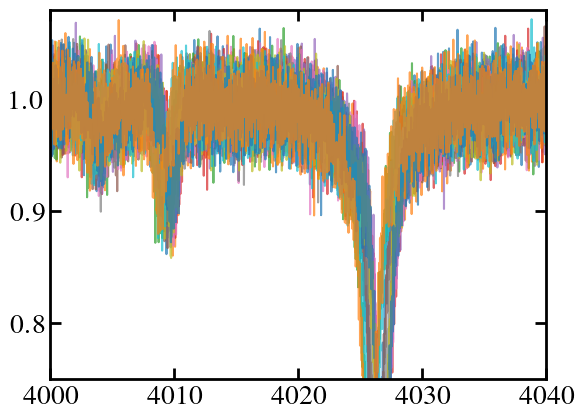

In [62]:
for yy in noisy_composite:
    plt.plot(wave1, yy, alpha=0.7)
plt.xlim(4000, 4040)
plt.ylim(0.75, 1.08)

In [68]:
for i, (flux, err) in enumerate(zip(noisy_composite, errors_frac), start=1):
    df = pd.DataFrame({
        "wavelength": wave1,
        "flux":       flux,
        "flux_err":   err,
    })
    df = df.query("3900 <= wavelength <= 4600")
    fname = f"ravel_tutorial/synth_spectra/synthetic_SB1_{i:02d}.txt"
    df.to_csv(fname, sep="\t", index=False)

## Create an SB2 system

In [69]:
observing_dict = {
    # 'ID' : np.array([f'epoch_{id}' for id in np.arange(1, N+1)]),
    'ID' : np.array(['star01']*N),
    # 'ID' : np.array([f'star01_{x}' for x in range(1, N+1)]),
    'MJD' : np.sort(mjds_night),
    'mean_rv' : np.random.uniform(20, 80, N),
    'mean_rv_er' : np.random.normal(0.1, 0.01, N),
}
df_obs = pd.DataFrame(observing_dict)
df_obs

,ID,MJD,mean_rv,mean_rv_er
0,star01,58064.911936,78.389239,0.107313
1,star01,58070.039663,79.065549,0.116732
2,star01,58177.066132,64.185792,0.107048
3,star01,58228.926794,55.369844,0.081977
4,star01,58416.992204,38.689347,0.111733
5,star01,58583.029603,69.625642,0.088727
6,star01,58637.981640,24.483354,0.102553
7,star01,58666.130396,77.443178,0.100832
8,star01,58699.075214,32.987721,0.101793
9,star01,58901.229115,43.518910,0.104052


In [163]:
simulator.M1_min = 12
simulator.M1_max = 14
simulator.q_min = 0.6
simulator.q_max = 0.7
simulator.logP_min = np.log10(12)
simulator.logP_max = np.log10(13)

coverage_dict = simulator.load_data(df_obs)

simsys = simulator.simulate_mock_observations(pi=0.0, kappa=0.0, eta=-0.5, gamma=-2.35, N=1, f_bin=1,)
simsys

,synthetic_ID,real_ID_used,is_binary,M1,q,P,Tp,e,omega_deg,gamma,K1,K2,i_deg,a,dRV_max,sigma_d,rv_mean,n_eps,rv_array,rv_array2
0,SYN_0000,star01,True,12.019749,0.653925,12.013853,11.917798,0.031961,280.522247,0.003446,41.691995,63.756555,155.261896,0.278095,81.141066,586.849392,2.067411,12,"[40.71768711512003, -28.693240714656167, -8.96...","[-61.947605518375475, 43.594871357680084, 13.6..."


In [ ]:
print('M2 = ', simsys['q'].values*simsys['M1'].values)

M2 =  [7.86001245]


In [165]:
simsys['rv_array'].to_list()

[array([ 40.71768712, -28.69324071,  -8.96285134, -34.40298556,
         -2.02631691,  35.94965329, -25.82480561,  41.85918986,
         -3.95328884, -39.28187654,  10.37676045,  39.05100681])]

In [166]:
simsys['rv_array2'].to_list()

[array([-61.94760552,  43.59487136,  13.66256996,  52.84783445,
          2.61942477, -54.86909013,  38.93766439, -64.16917267,
          6.30976328,  59.74133084, -16.1096475 , -60.29505493])]

[ 40.71768712 -28.69324071  -8.96285134 -34.40298556  -2.02631691
  35.94965329 -25.82480561  41.85918986  -3.95328884 -39.28187654
  10.37676045  39.05100681]


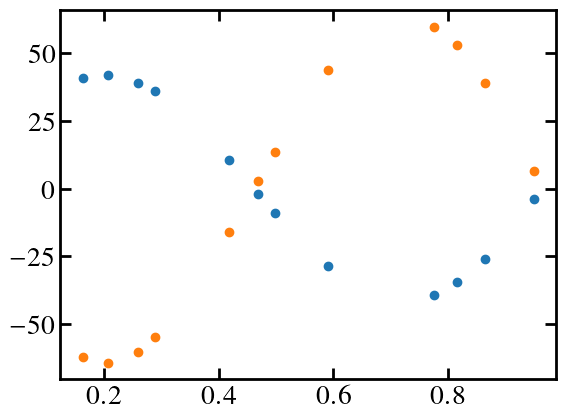

In [167]:
phase = (np.array(df_obs['MJD']) / simsys['P'].values) % 1
print(simsys['rv_array'].values[0])
plt.plot(phase, simsys['rv_array'].values[0], 'o', color='C0', label='simulated RVs primary')
plt.plot(phase, simsys['rv_array2'].values[0], 'o', color='C1', label='simulated RVs secondary')
# plt.errorbar(phase, simsys['rv_array'].values[0], yerr=df_obs['mean_rv_er'], fmt='o', color='C1', label='observed RVs')

Primary mass: 12.02 M_sun, Secondary mass: 7.86 M_sun
Primary star temeprature: 27000.0
Secondary star temeprature: 22000.0
Primary spectrum filename: gal-ob-vd3_27-42_line.txt
Length of flux after instrumental resolution: 49349
Length of flux after instrumental resolution: 49349
Primary fraction: 0.7761545753418307, Secondary fraction: 0.22384542465816926
Max dRV: 7


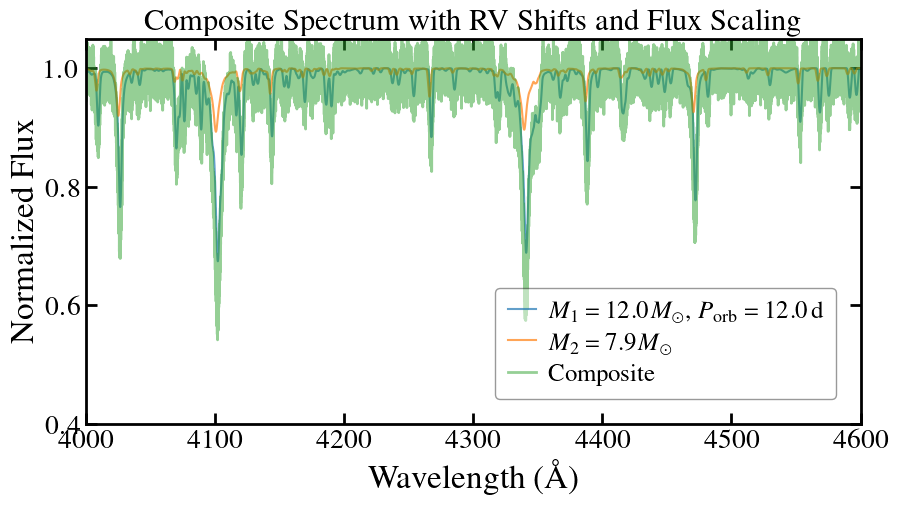

In [168]:
# 0. Define broadening and resolution parameters:
vsini = 100 # km/s
R = 5000      # Resolving power
snr = 50 # Signal-to-noise ratio

# 1. Get masses from the simulations:
masses1 = simsys['M1'].values
masses2 = simsys['q'].values * masses1
rvs1 = simsys['rv_array'].values
rvs2 = simsys['rv_array2'].values
periods = simsys['P'].values
drv_max = simsys['dRV_max'].values
all_cc_rvs = []
all_cc_peaks = []

# 2. Assign model parameters for each mass:
for m1, m2, rv1, rv2, drv, p in zip(masses1, masses2, rvs1, rvs2, drv_max, periods):
    print(f"Primary mass: {m1:.2f} M_sun, Secondary mass: {m2:.2f} M_sun")
    primary_model = assign_model_parameters(m1, models_data, target_logg=4.2)
    secondary_model = assign_model_parameters(m2, models_data, target_logg=4.2)
    print("Primary star temeprature:", primary_model['T_EFF'])
    print("Secondary star temeprature:", secondary_model['T_EFF'])
    # 3. Construct filenames for the models:
    primary_filename = construct_model_filename(primary_model)
    secondary_filename = construct_model_filename(secondary_model)
    print("Primary spectrum filename:", primary_filename)

    # 4. Read the model spectra:
    models = read_and_plot_model_spectra(primary_filename, secondary_filename, path=models_path, plot=False)

    # 5. Apply broadening and resolution to the models:
    wave1, flux1 = apply_broadening_and_resolution(models['primary'][0], models['primary'][1], vsini, R, epsilon=0.6, plot=False, xlim=(4535, 4565))
    wave2, flux2 = apply_broadening_and_resolution(models['secondary'][0], models['secondary'][1], vsini, R, epsilon=0.6, plot=False)

    # 6. Create the composite spectrum ():
    f_shift1, f_shift2, composite_flux = create_composite_spectrum(wave1, flux1, flux2, rv1, rv2, primary_model['LOGL'], secondary_model['LOGL'])
    shifted_primary = doppler_shift(wave1, flux1, rv1)

    # 7. Add noise to the composite spectrum:
    noisy_composite = add_noise(composite_flux, snr=snr)
    # noisy_composite = add_noise(shifted_primary, snr=snr)

    # 7b. Add errors to the flux
    # Constant fractional uncertainty (e.g. 5%)
    frac = 0.05
    errors_frac = np.abs( noisy_composite * frac )

    # if p < 20 and m2/m1 > 0.5:
    max_drv = np.argmax(np.abs(rv1 - rv2))
    print('Max dRV:', max_drv)
    plt.figure(figsize=(10, 5))
    plt.plot(wave1, f_shift1[max_drv], label=f"$M_1={m1:.1f}M_\odot$, $P_{{\\rm orb}}={p:.1f}\,$d", alpha=0.7)
    plt.plot(wave1, f_shift2[max_drv], label=f"$M_2={m2:.1f}M_\odot$", alpha=0.7)
    plt.plot(wave1, noisy_composite[max_drv], label="Composite", lw=2, alpha=0.5)
    plt.xlim(4000, 4600)
    plt.ylim(0.4, 1.05)
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    plt.legend()
    plt.title("Composite Spectrum with RV Shifts and Flux Scaling")
    plt.show()

#     # 8. Measure the RV from the composite spectrum:
#     cc_rv, cc_peak = measure_rv_cc(wave1, noisy_composite, flux1, velocity_range=(-450, 450), velocity_step=1.0, true_vel=rv1, wavelength_limits=(4000, 4600), plot_cc=False)
#     all_cc_rvs.append(cc_rv)
#     all_cc_peaks.append(cc_peak)

# if len(all_cc_rvs) == len(simsys):
#     simsys['CC_rvs'] = all_cc_rvs
#     simsys['CC_peaks'] = all_cc_peaks
#     print("\nSuccessfully added 'cc_rvs' and 'cc_peaks' columns to simsys.")
# else:
#     print(f"\nError: Number of results ({len(all_cc_rvs)}) does not match DataFrame length ({len(simsys)}). Columns not added.")

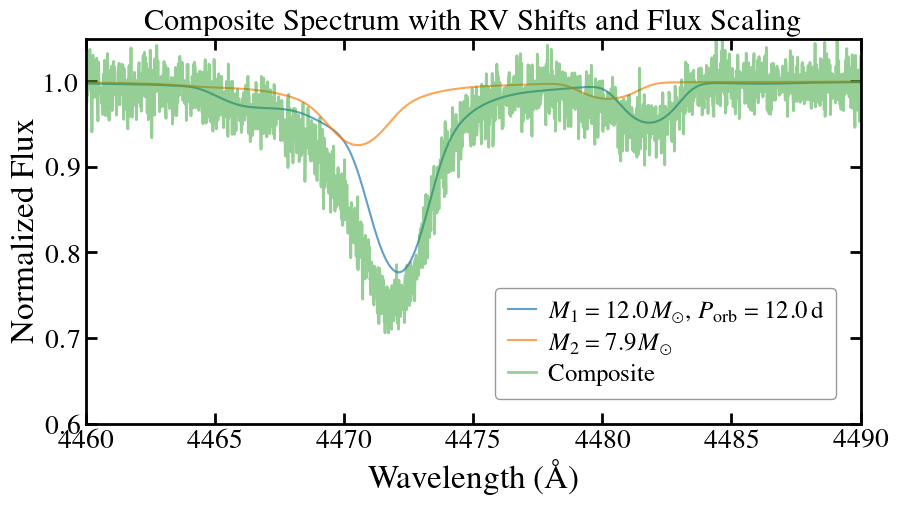

In [171]:
plt.figure(figsize=(10, 5))
plt.plot(wave1, f_shift1[max_drv], label=f"$M_1={m1:.1f}M_\odot$, $P_{{\\rm orb}}={p:.1f}\,$d", alpha=0.7)
plt.plot(wave1, f_shift2[max_drv], label=f"$M_2={m2:.1f}M_\odot$", alpha=0.7)
plt.plot(wave1, noisy_composite[max_drv], label="Composite", lw=2, alpha=0.5)
plt.xlim(4460, 4490)
plt.ylim(0.6, 1.05)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.legend()
plt.title("Composite Spectrum with RV Shifts and Flux Scaling")
plt.show()

In [170]:
for i, (flux, err) in enumerate(zip(noisy_composite, errors_frac), start=1):
    df = pd.DataFrame({
        "wavelength": wave1,
        "flux":       flux,
        "flux_err":   err,
    })
    df = df.query("3900 <= wavelength <= 4600")
    fname = f"ravel_tutorial/synth_spectra/synthetic_SB2_{i:02d}.txt"
    df.to_csv(fname, sep="\t", index=False)

In [172]:
observing_dict = {
    # 'ID' : np.array([f'epoch_{id}' for id in np.arange(1, N+1)]),
    # 'ID' : np.array(['star01']*N),
    'ID' : np.array([f'star01_{x}' for x in range(1, N+1)]),
    'MJD' : np.sort(mjds_night),
    'mean_rv' : np.random.uniform(20, 80, N),
    'mean_rv_er' : np.random.normal(0.1, 0.01, N),
}
df_obs = pd.DataFrame(observing_dict)
df_obs

,ID,MJD,mean_rv,mean_rv_er
0,star01_1,58064.911936,71.453597,0.098889
1,star01_2,58070.039663,72.576468,0.112649
2,star01_3,58177.066132,63.058172,0.091933
3,star01_4,58228.926794,55.066963,0.091691
4,star01_5,58416.992204,56.516870,0.099267
5,star01_6,58583.029603,55.266125,0.103859
6,star01_7,58637.981640,50.437464,0.102322
7,star01_8,58666.130396,42.377865,0.105567
8,star01_9,58699.075214,43.832948,0.087983
9,star01_10,58901.229115,34.796159,0.101627


In [174]:
df_obs.to_csv('ravel_tutorial/SB2/SB2/JDs.txt', index=False, sep=' ', header=False, columns=['ID', 'MJD'])

### Easier case

In [175]:
observing_dict = {
    # 'ID' : np.array([f'epoch_{id}' for id in np.arange(1, N+1)]),
    'ID' : np.array(['star01']*N),
    # 'ID' : np.array([f'star01_{x}' for x in range(1, N+1)]),
    'MJD' : np.sort(mjds_night),
    'mean_rv' : np.random.uniform(20, 80, N),
    'mean_rv_er' : np.random.normal(0.1, 0.01, N),
}
df_obs = pd.DataFrame(observing_dict)
df_obs

,ID,MJD,mean_rv,mean_rv_er
0,star01,58064.911936,78.298203,0.104753
1,star01,58070.039663,55.657340,0.094180
2,star01,58177.066132,31.424524,0.125439
3,star01,58228.926794,49.707865,0.108919
4,star01,58416.992204,66.404830,0.098657
5,star01,58583.029603,65.861190,0.112675
6,star01,58637.981640,57.542082,0.076137
7,star01,58666.130396,63.531063,0.115506
8,star01,58699.075214,25.851620,0.091891
9,star01,58901.229115,61.165643,0.095065


In [176]:
simulator.M1_min = 12
simulator.M1_max = 14
simulator.q_min = 0.7
simulator.q_max = 0.78
simulator.logP_min = np.log10(10)
simulator.logP_max = np.log10(11)

coverage_dict = simulator.load_data(df_obs)

simsys = simulator.simulate_mock_observations(pi=0.0, kappa=0.0, eta=-0.5, gamma=-2.35, N=1, f_bin=1,)
simsys

,synthetic_ID,real_ID_used,is_binary,M1,q,P,Tp,e,omega_deg,gamma,K1,K2,i_deg,a,dRV_max,sigma_d,rv_mean,n_eps,rv_array,rv_array2
0,SYN_0000,star01,True,12.227898,0.736989,10.456748,3.245261,0.011288,125.631296,-0.353926,102.259329,138.752893,63.28886,0.259168,181.885034,1299.249041,-32.555423,12,"[82.764482994429, -82.05452626852852, -69.7135...","[-112.95898449462061, 110.18779750473719, 93.6..."


In [177]:
print('M2 = ', simsys['q'].values*simsys['M1'].values)

M2 =  [9.01182398]


In [178]:
simsys['rv_array'].to_list()

[array([ 82.76448299, -82.05452627, -69.71351362, -86.48313609,
        -91.27318937, -99.12055103, -26.29279679, -83.8487849 ,
        -97.48034492,  74.30189936,  13.10191676,  75.43347374])]

In [179]:
simsys['rv_array2'].to_list()

[array([-112.95898449,  110.1877975 ,   93.6356024 ,  116.53873229,
         123.27646219,  133.77296068,   34.61141278,  113.35778357,
         131.57734988, -101.6643094 ,  -18.52962267, -103.26468563])]

[ 82.76448299 -82.05452627 -69.71351362 -86.48313609 -91.27318937
 -99.12055103 -26.29279679 -83.8487849  -97.48034492  74.30189936
  13.10191676  75.43347374]


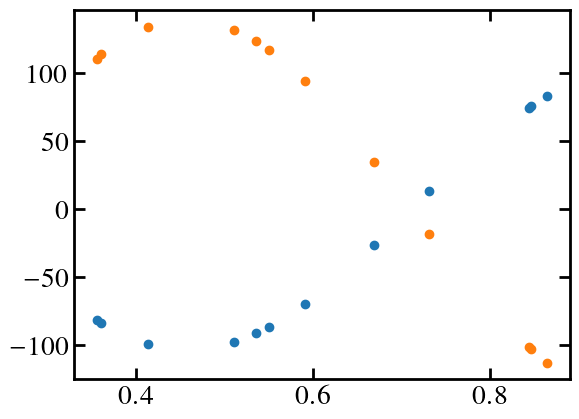

In [180]:
phase = (np.array(df_obs['MJD']) / simsys['P'].values) % 1
print(simsys['rv_array'].values[0])
plt.plot(phase, simsys['rv_array'].values[0], 'o', color='C0', label='simulated RVs primary')
plt.plot(phase, simsys['rv_array2'].values[0], 'o', color='C1', label='simulated RVs secondary')

Primary mass: 12.23 M_sun, Secondary mass: 9.01 M_sun
Primary star temeprature: 28000.0
Secondary star temeprature: 24000.0
Primary spectrum filename: gal-ob-vd3_28-42_line.txt
Length of flux after instrumental resolution: 49349
Length of flux after instrumental resolution: 49349
Primary fraction: 0.719919005947152, Secondary fraction: 0.28008099405284803
Max dRV: 5


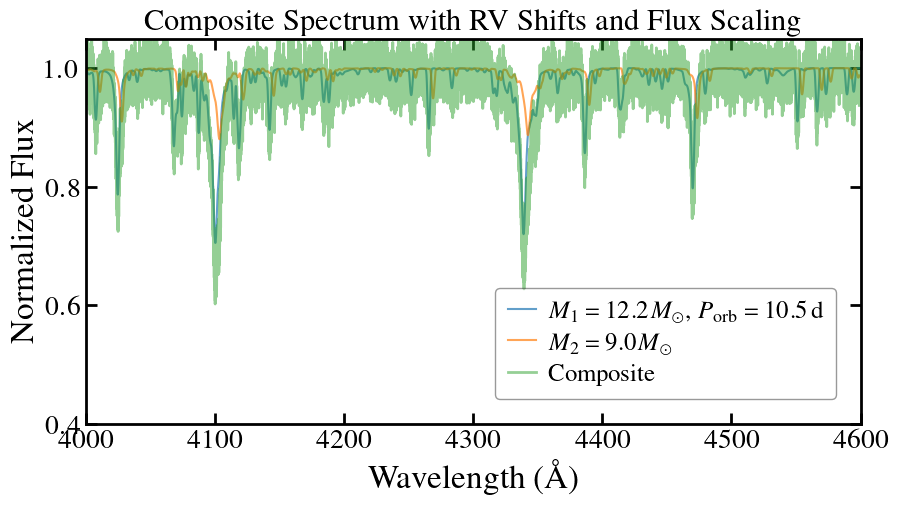

In [181]:
# 0. Define broadening and resolution parameters:
vsini = 100 # km/s
R = 5000      # Resolving power
snr = 50 # Signal-to-noise ratio

# 1. Get masses from the simulations:
masses1 = simsys['M1'].values
masses2 = simsys['q'].values * masses1
rvs1 = simsys['rv_array'].values
rvs2 = simsys['rv_array2'].values
periods = simsys['P'].values
drv_max = simsys['dRV_max'].values
all_cc_rvs = []
all_cc_peaks = []

# 2. Assign model parameters for each mass:
for m1, m2, rv1, rv2, drv, p in zip(masses1, masses2, rvs1, rvs2, drv_max, periods):
    print(f"Primary mass: {m1:.2f} M_sun, Secondary mass: {m2:.2f} M_sun")
    primary_model = assign_model_parameters(m1, models_data, target_logg=4.2)
    secondary_model = assign_model_parameters(m2, models_data, target_logg=4.2)
    print("Primary star temeprature:", primary_model['T_EFF'])
    print("Secondary star temeprature:", secondary_model['T_EFF'])
    # 3. Construct filenames for the models:
    primary_filename = construct_model_filename(primary_model)
    secondary_filename = construct_model_filename(secondary_model)
    print("Primary spectrum filename:", primary_filename)

    # 4. Read the model spectra:
    models = read_and_plot_model_spectra(primary_filename, secondary_filename, path=models_path, plot=False)

    # 5. Apply broadening and resolution to the models:
    wave1, flux1 = apply_broadening_and_resolution(models['primary'][0], models['primary'][1], vsini, R, epsilon=0.6, plot=False, xlim=(4535, 4565))
    wave2, flux2 = apply_broadening_and_resolution(models['secondary'][0], models['secondary'][1], vsini, R, epsilon=0.6, plot=False)

    # 6. Create the composite spectrum ():
    f_shift1, f_shift2, composite_flux = create_composite_spectrum(wave1, flux1, flux2, rv1, rv2, primary_model['LOGL'], secondary_model['LOGL'])
    shifted_primary = doppler_shift(wave1, flux1, rv1)

    # 7. Add noise to the composite spectrum:
    noisy_composite = add_noise(composite_flux, snr=snr)
    # noisy_composite = add_noise(shifted_primary, snr=snr)

    # 7b. Add errors to the flux
    # Constant fractional uncertainty (e.g. 5%)
    frac = 0.05
    errors_frac = np.abs( noisy_composite * frac )

    # if p < 20 and m2/m1 > 0.5:
    max_drv = np.argmax(np.abs(rv1 - rv2))
    print('Max dRV:', max_drv)
    plt.figure(figsize=(10, 5))
    plt.plot(wave1, f_shift1[max_drv], label=f"$M_1={m1:.1f}M_\odot$, $P_{{\\rm orb}}={p:.1f}\,$d", alpha=0.7)
    plt.plot(wave1, f_shift2[max_drv], label=f"$M_2={m2:.1f}M_\odot$", alpha=0.7)
    plt.plot(wave1, noisy_composite[max_drv], label="Composite", lw=2, alpha=0.5)
    plt.xlim(4000, 4600)
    plt.ylim(0.4, 1.05)
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    plt.legend()
    plt.title("Composite Spectrum with RV Shifts and Flux Scaling")
    plt.show()

#     # 8. Measure the RV from the composite spectrum:
#     cc_rv, cc_peak = measure_rv_cc(wave1, noisy_composite, flux1, velocity_range=(-450, 450), velocity_step=1.0, true_vel=rv1, wavelength_limits=(4000, 4600), plot_cc=False)
#     all_cc_rvs.append(cc_rv)
#     all_cc_peaks.append(cc_peak)

# if len(all_cc_rvs) == len(simsys):
#     simsys['CC_rvs'] = all_cc_rvs
#     simsys['CC_peaks'] = all_cc_peaks
#     print("\nSuccessfully added 'cc_rvs' and 'cc_peaks' columns to simsys.")
# else:
#     print(f"\nError: Number of results ({len(all_cc_rvs)}) does not match DataFrame length ({len(simsys)}). Columns not added.")

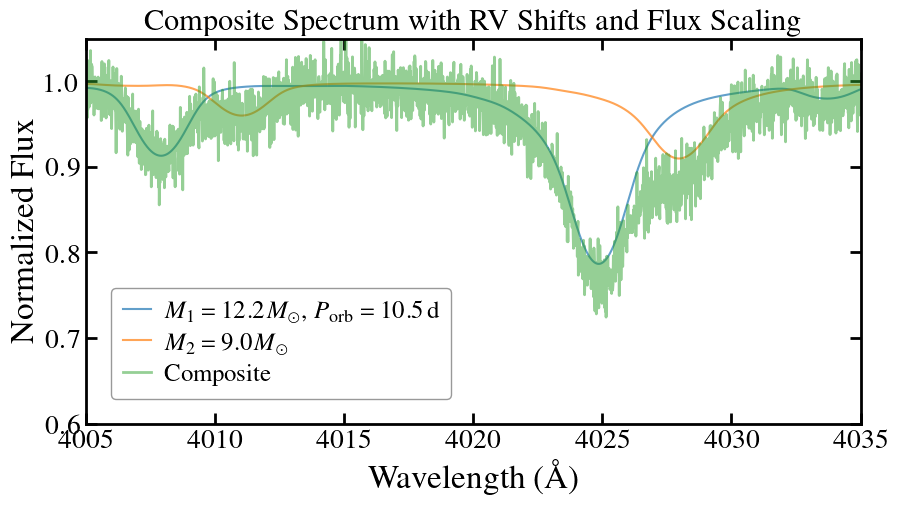

In [190]:
plt.figure(figsize=(10, 5))
plt.plot(wave1, f_shift1[max_drv], label=f"$M_1={m1:.1f}M_\odot$, $P_{{\\rm orb}}={p:.1f}\,$d", alpha=0.7)
plt.plot(wave1, f_shift2[max_drv], label=f"$M_2={m2:.1f}M_\odot$", alpha=0.7)
plt.plot(wave1, noisy_composite[max_drv], label="Composite", lw=2, alpha=0.5)
plt.xlim(4005, 4035)
plt.ylim(0.6, 1.05)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.legend()
plt.title("Composite Spectrum with RV Shifts and Flux Scaling")
plt.show()

In [187]:
for i, (flux, err) in enumerate(zip(noisy_composite, errors_frac), start=1):
    df = pd.DataFrame({
        "wavelength": wave1,
        "flux":       flux,
        "flux_err":   err,
    })
    df = df.query("3900 <= wavelength <= 4600")
    fname = f"ravel_tutorial/synth_spectra/synthetic_case2_SB2_{i:02d}.txt"
    df.to_csv(fname, sep="\t", index=False)

In [188]:
observing_dict = {
    # 'ID' : np.array([f'epoch_{id}' for id in np.arange(1, N+1)]),
    # 'ID' : np.array(['star01']*N),
    'ID' : np.array([f'star01_{x}' for x in range(1, N+1)]),
    'MJD' : np.sort(mjds_night),
    'mean_rv' : np.random.uniform(20, 80, N),
    'mean_rv_er' : np.random.normal(0.1, 0.01, N),
}
df_obs = pd.DataFrame(observing_dict)
df_obs

,ID,MJD,mean_rv,mean_rv_er
0,star01_1,58064.911936,47.841025,0.101018
1,star01_2,58070.039663,43.524112,0.108728
2,star01_3,58177.066132,66.060796,0.091455
3,star01_4,58228.926794,46.962377,0.092256
4,star01_5,58416.992204,78.143529,0.080797
5,star01_6,58583.029603,77.480835,0.101284
6,star01_7,58637.981640,34.303237,0.101820
7,star01_8,58666.130396,71.102405,0.104192
8,star01_9,58699.075214,64.624636,0.085807
9,star01_10,58901.229115,21.355513,0.096204


In [189]:
df_obs.to_csv('ravel_tutorial/SB2_2/SB2/JDs.txt', index=False, sep=' ', header=False, columns=['ID', 'MJD'])